# Relatório Projeto Aplicado - Smart Crop Irrigation Grid: Avaliação de Algoritmos de RL Inteligente

**Integrantes do Grupo:**
* Gregory Stein
* Jackson Pandolfo
* Lucas Toledo

Neste projeto, avaliamos três algoritmos de Aprendizado por Reforço Profundo (PPO, DQN e A2C) na resolução de um problema logístico em agricultura de precisão. O objetivo é treinar um robô autônomo para gerenciar a umidade de uma plantação em um grid 5x5, regando quando necessário, colhendo no momento ideal e entregando os itens na base.

**Visão Geral e Descobertas:**
A dificuldade central do ambiente é a **esparsidade de recompensas**: o agente perde pontos a cada passo e a cada planta morta, mas só recebe a pontuação ótima (+20) ao concluir toda a cadeia de passos (regar -> colher -> navegar até a base -> descarregar). Nossos experimentos revelaram que algoritmos *off-policy* (como o DQN) lidam melhor com esse cenário graças à memória de longo prazo (*Replay Buffer*). Em contrapartida, algoritmos *on-policy* (PPO e A2C) sofrem de "miopia de recompensa" e gestão ineficiente de inventário, exigindo uma técnica rigorosa de *Reward Shaping* (punições por inatividade e colisão) para resolver o problema com sucesso.

**Abaixo a classe de Smart Crop Irrigation implementada.**

In [6]:
# Implementação de referência incorporada para dispensar o arquivo .py externo.
# Corresponde à V2 fornecida para o DQN; não reconstitui versões históricas PPO/A2C.
# Requer Gymnasium e NumPy somente ao executar esta célula.
import gymnasium as gym
from gymnasium import spaces
import numpy as np


class SmartCropIrrigationEnv(gym.Env):
    """
    Ambiente Customizado: Smart Crop Irrigation Grid
    """

    metadata = {"render_modes": ["human", "rgb_array"], "render_fps": 4}

    def __init__(self, grid_size=5, max_steps=250, render_mode=None, dry_rate=0.08,
                 border_penalty=1.0, idle_penalty=0.5):
        super().__init__()

        self.grid_size = grid_size
        self.max_steps = max_steps
        self.current_step = 0
        # Chance por passo de cada planta secar 1 nível. Era 0.15 fixo no código
        # (testamos: matava uma planta esquecida em ~13 passos, rápido demais pro
        # agente conseguir colher o grid inteiro a tempo). Exposto como parâmetro
        # pra poder testar valores diferentes nos experimentos.
        self.dry_rate = dry_rate
        # Variante de recompensa: valores positivos são subtraídos em step().
        if not np.isfinite(border_penalty) or not np.isfinite(idle_penalty) or border_penalty < 0 or idle_penalty < 0:
            raise ValueError("As penalidades devem ser finitas e não negativas.")
        self.border_penalty = float(border_penalty)
        self.idle_penalty = float(idle_penalty)

        # Posição da base
        self.base_pos = np.array([0, 0])

        assert render_mode is None or render_mode in self.metadata["render_modes"]
        self.render_mode = render_mode

        # Estado da janela do Pygame (só é criada na primeira chamada de render)
        self.cell_size = 60
        self.info_bar_height = 40
        self.window_size = self.grid_size * self.cell_size
        self.window = None
        self.clock = None

        # 8 Ações: 0: Cima, 1: Baixo, 2: Esq, 3: Dir, 4: Regar, 5: Colher, 6: Descarregar, 7: Esperar
        self.action_space = spaces.Discrete(8)

        # Espaço de Observação usando Dict
        self.observation_space = spaces.Dict(
            {
                "robot_pos": spaces.MultiDiscrete([self.grid_size, self.grid_size]),
                "inventory": spaces.Discrete(4),  # 0 a 3 plantas
                # Matriz de umidade: 0 (morta) a 4 (encharcada). Usando Box para facilitar a representação 2D.
                "grid_moisture": spaces.Box(
                    low=0, high=4, shape=(self.grid_size, self.grid_size), dtype=np.int8
                ),
                "cell_moisture": spaces.Box(
                    low=0,
                    high=4,
                    shape=(1,),
                    dtype=np.int8,
                ),
                "at_base": spaces.Discrete(2),
            }
        )

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)

        self.current_step = 0
        self.robot_pos = np.copy(self.base_pos)
        self.inventory = 0

        # Inicializa o grid com as plantas no nível ideal de umidade (2)
        self.grid_moisture = np.full((self.grid_size, self.grid_size), 2, dtype=np.int8)
        # Correção: a base [0,0] não é uma planta, então não pode nascer com umidade 2
        # (senão ela vira colhível/regável como qualquer célula, e o agente precisaria
        # "colher a base" pra vencer). Fica em 0, o mesmo valor usado pra célula sem planta.
        self.grid_moisture[0, 0] = 0
        # Exclusivamente visual: diferencia morte de coleta, ambas com umidade 0.
        # Não integra a observação nem modifica recompensas ou decisões.
        self.dead_cells = np.zeros((self.grid_size, self.grid_size), dtype=bool)

        # Total de plantas que existem no grid (tudo, menos a base) e quantas já
        # foram entregues. Usado pra condição de sucesso (ver step()).
        self.total_plants = self.grid_size * self.grid_size - 1
        self.plants_delivered = 0

        observation = self._get_obs()
        info = self._get_info()

        if self.render_mode == "human":
            self.render()

        return observation, info

    def step(self, action):
        self.current_step += 1
        reward = -0.1  # Penalidade padrão por passo (tempo)
        terminated = False
        truncated = False

        previous_pos = self.robot_pos.copy()
        blocked_move = False
        idle_with_plants = False

        # 1. Processar a Ação do Agente
        if action == 0:  # Cima
            self.robot_pos[0] = max(0, self.robot_pos[0] - 1)
        elif action == 1:  # Baixo
            self.robot_pos[0] = min(self.grid_size - 1, self.robot_pos[0] + 1)
        elif action == 2:  # Esquerda
            self.robot_pos[1] = max(0, self.robot_pos[1] - 1)
        elif action == 3:  # Direita
            self.robot_pos[1] = min(self.grid_size - 1, self.robot_pos[1] + 1)

        elif action == 4:  # Regar
            r, c = self.robot_pos
            # Correção: só recompensa regar quando a planta está abaixo do nível ideal (2).
            # Antes também recompensava regar uma planta já no nível ideal, o que a
            # empurrava pra fora do nível colhível — um incentivo contra o próprio objetivo.
            if self.grid_moisture[r, c] > 0 and self.grid_moisture[r, c] < 2:
                self.grid_moisture[r, c] += 1  # Aumenta 1 nível
                reward += 1  # Recompensa por regar
            else:
                reward -= 1  # Penalidade por regar planta morta, já ideal ou encharcada

        elif action == 5:  # Colher
            r, c = self.robot_pos
            if self.inventory < 3:
                if self.grid_moisture[r, c] == 2:
                    self.inventory += 1
                    self.grid_moisture[r, c] = (
                        0  # Planta colhida (vira 'célula vazia/morta')
                    )
                    reward += 5
                else:
                    reward -= 2  # Penalidade por colher fora do nível ideal
            else:
                reward -= 1  # Inventário cheio

        elif action == 6:  # Descarregar
            if np.array_equal(self.robot_pos, self.base_pos) and self.inventory > 0:
                reward += 20 * self.inventory  # +20 por planta entregue
                self.plants_delivered += self.inventory
                self.inventory = 0
            else:
                reward -= 1  # Tentar descarregar fora da base ou vazio

        elif action == 7:  # Esperar
            # Avalia antes da secagem: 1 precisa de água, 2 pode ser colhida.
            idle_with_plants = bool(
                np.any(
                    (self.grid_moisture == 1) | (self.grid_moisture == 2)
                )
                or self.inventory > 0
            )
            if idle_with_plants:
                reward -= self.idle_penalty

        if action in (0, 1, 2, 3) and np.array_equal(previous_pos, self.robot_pos):
            blocked_move = True
            reward -= self.border_penalty

        # 2. Dinâmica do Ambiente (Secagem estocástica)
        deaths = self._apply_moisture_decay()
        # Penalidade por negligência: sem isso, deixar uma planta morrer só custava a
        # recompensa futura perdida (colher/entregar), um sinal indireto e atrasado.
        reward -= 2 * deaths

        # 3. Condições de Parada
        if self.current_step >= self.max_steps:
            truncated = True

        # Condição de Sucesso: todas as plantas do grid foram colhidas E entregues na base.
        # Correção: antes checava só "grid todo zerado", mas uma planta que morre de sede
        # também vira 0 — então o agente "vencia" só esperando o grid secar sozinho, sem
        # nunca colher nada. Agora exige contar entregas de verdade (self.plants_delivered).
        # Encerra com sucesso ou quando não existe mais trabalho possível.
        if self.plants_delivered >= self.total_plants:
            terminated = True
        elif not np.any(self.grid_moisture > 0) and self.inventory == 0:
            terminated = True

        observation = self._get_obs()
        info = self._get_info()

        if self.render_mode == "human":
            self.render()

        info.update({
            "blocked_move": blocked_move,
            "idle_with_plants": idle_with_plants,
            "border_penalty_applied": self.border_penalty if blocked_move else 0.0,
            "idle_penalty_applied": self.idle_penalty if idle_with_plants else 0.0,
        })
        return observation, reward, terminated, truncated, info

    def _apply_moisture_decay(self):
        # Chance por passo (self.dry_rate) de cada planta secar 1 nível. Retorna
        # quantas morreram neste passo (chegaram a 0), pra aplicar penalidade em step().
        deaths = 0
        for r in range(self.grid_size):
            for c in range(self.grid_size):
                # Ignora se estiver morta/colhida (0) ou se for a base [0,0]
                if self.grid_moisture[r, c] > 0 and not (r == 0 and c == 0):
                    if self.np_random.random() < self.dry_rate:
                        self.grid_moisture[r, c] -= 1
                        if self.grid_moisture[r, c] == 0:
                            deaths += 1
                            self.dead_cells[r, c] = True
        return deaths

    def _get_obs(self):
        return {
            "robot_pos": self.robot_pos.copy(),
            "inventory": self.inventory,
            "grid_moisture": self.grid_moisture.copy(),
            "cell_moisture": np.array(
                [self.grid_moisture[tuple(self.robot_pos)]],
                dtype=np.int8,
            ),
            "at_base": int(
                np.array_equal(self.robot_pos, self.base_pos)
            ),
        }

    def _get_info(self):
        return {"current_step": self.current_step}

    # Cores por nível de umidade (0 = sem planta/morta, 2 = ideal, 4 = encharcada).
    # Níveis 3 e 4 hoje nunca ocorrem de fato: a ação Regar para de funcionar a partir
    # do nível 2 (ver step()). Ficam mapeados aqui caso essa regra mude no futuro.
    _MOISTURE_COLORS = {
        0: (120, 100, 80),
        1: (194, 178, 128),
        2: (76, 175, 80),
        3: (46, 125, 50),
        4: (33, 90, 160),
    }

    def render(self):
        if self.render_mode is None:
            gym.logger.warn(
                "Chamou render() sem definir render_mode no construtor (use 'human' ou 'rgb_array')."
            )
            return
        return self._render_frame()

    def _render_frame(self):
        import pygame

        if not pygame.get_init():
            pygame.init()  # inicializa também o módulo de fontes, usado em ambos os modos

        if self.window is None and self.render_mode == "human":
            pygame.display.init()
            pygame.display.set_caption("Smart Crop Irrigation Grid")
            self.window = pygame.display.set_mode(
                (self.window_size, self.window_size + self.info_bar_height)
            )
        if self.clock is None and self.render_mode == "human":
            self.clock = pygame.time.Clock()

        canvas = pygame.Surface((self.window_size, self.window_size + self.info_bar_height))
        canvas.fill((255, 255, 255))

        # Grid: uma célula por planta, colorida conforme o nível de umidade
        for r in range(self.grid_size):
            for c in range(self.grid_size):
                rect = pygame.Rect(
                    c * self.cell_size, r * self.cell_size, self.cell_size, self.cell_size
                )
                level = int(self.grid_moisture[r, c])
                pygame.draw.rect(canvas, self._MOISTURE_COLORS[level], rect)
                pygame.draw.rect(canvas, (0, 0, 0), rect, width=1)
                if self.dead_cells[r, c]:
                    margin = self.cell_size // 4
                    x0, y0 = c * self.cell_size, r * self.cell_size
                    color = (230, 35, 45)
                    pygame.draw.line(canvas, color,
                                     (x0 + margin, y0 + margin),
                                     (x0 + self.cell_size - margin, y0 + self.cell_size - margin), 4)
                    pygame.draw.line(canvas, color,
                                     (x0 + self.cell_size - margin, y0 + margin),
                                     (x0 + margin, y0 + self.cell_size - margin), 4)

        # Base: contorno dourado sobre a célula [0,0], pra não confundir com planta morta
        base_rect = pygame.Rect(
            int(self.base_pos[1]) * self.cell_size,
            int(self.base_pos[0]) * self.cell_size,
            self.cell_size,
            self.cell_size,
        )
        pygame.draw.rect(canvas, (255, 215, 0), base_rect, width=4)

        # Robô
        robot_center = (
            int(self.robot_pos[1]) * self.cell_size + self.cell_size // 2,
            int(self.robot_pos[0]) * self.cell_size + self.cell_size // 2,
        )
        pygame.draw.circle(canvas, (20, 20, 20), robot_center, self.cell_size // 3)

        # Inventário: até 3 quadrados, preenchido = planta carregada
        slot_size = 16
        for i in range(3):
            slot_rect = pygame.Rect(
                8 + i * (slot_size + 4), self.window_size + 12, slot_size, slot_size
            )
            color = (76, 175, 80) if i < self.inventory else (255, 255, 255)
            pygame.draw.rect(canvas, color, slot_rect)
            pygame.draw.rect(canvas, (0, 0, 0), slot_rect, width=1)

        # Passos: barra de progresso até o timeout
        bar_x = 8 + 3 * (slot_size + 4) + 12
        bar_width = self.window_size - bar_x - 8
        progress = self.current_step / self.max_steps
        pygame.draw.rect(
            canvas, (200, 200, 200), (bar_x, self.window_size + 12, bar_width, slot_size)
        )
        pygame.draw.rect(
            canvas,
            (33, 90, 160),
            (bar_x, self.window_size + 12, int(bar_width * progress), slot_size),
        )
        pygame.draw.rect(
            canvas, (0, 0, 0), (bar_x, self.window_size + 12, bar_width, slot_size), width=1
        )

        if self.render_mode == "human":
            self.window.blit(canvas, canvas.get_rect())
            pygame.event.pump()
            pygame.display.update()
            self.clock.tick(self.metadata["render_fps"])
        else:  # rgb_array
            return np.transpose(np.array(pygame.surfarray.pixels3d(canvas)), axes=(1, 0, 2))

    def close(self):
        # Só limpa o pygame se uma janela de verdade foi criada (render_mode="human").
        # Em "rgb_array" o pygame.init() roda mas nunca é encerrado aqui - inofensivo
        if self.window is not None:
            import pygame

            pygame.display.quit()
            pygame.quit()
            self.window = None
            self.clock = None

# Disponibiliza o módulo em memória para o import já existente no relatório.
import sys
import types
_modulo_crop = types.ModuleType("smart_crop_irrigation_V2")
_modulo_crop.SmartCropIrrigationEnv = SmartCropIrrigationEnv
sys.modules["smart_crop_irrigation_V2"] = _modulo_crop


In [7]:
# Importações base e verificação do ambiente
import gymnasium as gym
from stable_baselines3 import PPO, DQN, A2C
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.monitor import Monitor
from smart_crop_irrigation_V2 import SmartCropIrrigationEnv

# Instanciando o ambiente com punições ativas (Reward Shaping)
env = SmartCropIrrigationEnv(
    grid_size=5,
    max_steps=250,
    dry_rate=0.02,        # Taxa mitigada para estender a janela de sobrevivência
    border_penalty=1.0,   # Punição por colisão
    idle_penalty=0.5      # Punição por inatividade
)
print("Ambiente V2 carregado com sucesso. Espaço de Ação:", env.action_space)

Ambiente V2 carregado com sucesso. Espaço de Ação: Discrete(8)


## 1. Modelagem do Problema (MDP)

O ambiente foi modelado como um Processo de Decisão de Markov (MDP) customizado no `gymnasium`, definido pela tupla $(S, A, T, R)$:

* **Estado ($S$):** O espaço de observação é um dicionário (`spaces.Dict`) contendo a posição do robô (x, y), a ocupação do inventário (0 a 3 plantas), uma matriz 2D representando a umidade do grid (níveis de 0 a 4) e um indicador booleano de presença na base.
* **Ações ($A$):** O espaço de ações é discreto (`spaces.Discrete(8)`), permitindo 8 comandos: Mover (Cima, Baixo, Esquerda, Direita), Regar, Colher, Descarregar e Esperar.
* **Transição ($T$):** As movimentações do robô são determinísticas. No entanto, o ambiente possui transições estocásticas baseadas na degradação temporal: a cada passo, há uma probabilidade (`dry_rate`) de as plantas secarem e morrerem.
* **Recompensa ($R$):** A função de recompensa original é esparsa (+20 por entrega, +5 por colheita correta, -0.1 por passo, -2 por morte da planta). Para os testes avançados (Ambiente V2), aplicamos *Reward Shaping* punitivo: -1.0 por tentar sair dos limites do grid e -0.5 por inatividade.

## 2. Metodologia de Experimentos

Para avaliar a viabilidade de controle do robô, implementamos três arquiteturas de redes neurais do pacote `stable_baselines3`:
1. **DQN (Deep Q-Network):** Representando as políticas *off-policy*, utilizando *Replay Buffer* para reaproveitar experiências passadas.
2. **PPO (Proximal Policy Optimization):** Algoritmo *on-policy* padrão, conhecido por sua estabilidade de atualização.
3. **A2C (Advantage Actor-Critic):** Algoritmo *on-policy* clássico e síncrono.

**Métricas e Hiperparâmetros:**
A avaliação utiliza recompensa média e taxa de entregas, definida como a proporção das 24 plantas efetivamente entregues. A taxa de sucesso completo mede, separadamente, a proporção de episódios com 24/24 entregas. Os testes iniciais de PPO e A2C incluíram benchmarks de 150.000 passos, seguidos de treinamentos mais longos. O benchmark DQN consolidado utilizou 300.000 passos por configuração. Foram investigados hiperparâmetros como learning_rate, batch_size, n_steps, ent_coef e, no DQN, exploration_fraction, conforme os experimentos apresentados nas respectivas seções.

## 3. Avaliação do A2C, PPO e DQN

## 3.1. Avaliação do A2C
O algoritmo A2C (*Advantage Actor-Critic*), sendo *on-policy* e sem Replay Buffer, foi o que mais sofreu com a formulação inicial do problema.

### O Colapso de Política (Baseline)
Com a taxa de secagem alta (`dry_rate=0.08`) e a versão clássica do ambiente, todas as 6 configurações do A2C travaram exatamente em **-73.0** pontos.

O agente sofreu de **Miopia de Recompensa**: ao explorar e cometer erros, acumulou tantas punições que a rede neural calculou que a estratégia matematicamente mais segura era fugir para o canto do grid e ficar parado, aceitando a penalidade de -73.0 para evitar perdas maiores.

### A Intervenção: Reward Shaping (Ambiente V2) e Mitigação de Sobrevivência
Para forçar o A2C a sair do "ótimo local", foi implementado no `smart_crop_irrigation_V2` penalidades caso o agente permaneça inerte ou nas bordas do grid, junto de uma redução da taxa de secagem das plantas(`dry_rate=0.02`).
* **-1.0** por colisão nas bordas.
* **-0.5** por inatividade.

Essas configurações forçaram o agente a sair e explorar o grid, trazendo resultados constantes.

In [8]:
# A configuração matemática que resolveu o colapso do A2C
# A alta entropia (0.1) aliada ao Reward Shaping V2 permitiu a otimização da rota
a2c_winner_params = {
    "learning_rate": 7e-4,
    "n_steps": 5,
    "gamma": 0.99,
    "ent_coef": 0.1 # Nível Extremo de Exploração
}

print("Hiperparâmetros A2C (Otimização Final):", a2c_winner_params)

Hiperparâmetros A2C (Otimização Final): {'learning_rate': 0.0007, 'n_steps': 5, 'gamma': 0.99, 'ent_coef': 0.1}


### 3.1.1. Análise Técnica e A2C

Após 300.000 passos com a configuração `exploracao_extrema` e o *Reward Shaping* ativo, o A2C performou de forma muito mais eficaz, comparado com os treinos iniciais:
* **Média no Benchmark:** 314.2 pontos (superando com folga o colapso de -73.0).
* **Capacidade Logística:** O robô compreendeu o inventário. Passou a coletar de 3 em 3 plantas antes de retornar à base.
* **Volume de Entregas:** Atingiu de 15 a 20 plantas entregues por episódio.


## 3.2. Avaliação do PPO
O PPO (*Proximal Policy Optimization*), apesar de também ser *on-policy*, permitiu uma investigação mais profunda por já contar com um espaço de observação e ambiente validados desde as fases iniciais do projeto.

### Bugs Corrigidos no Ambiente (Fase 1.1)
Antes de qualquer otimização de hiperparâmetros, três bugs foram identificados e corrigidos na classe `SmartCropIrrigationEnv`: (1) a célula da base era tratada como uma planta comum, podendo ser regada e colhida; (2) regar uma planta já no nível ideal era recompensado, empurrando-a para fora do nível colhível; (3) a condição de sucesso podia ser satisfeita por negligência, já que uma planta morta de sede e uma planta colhida ficam com o mesmo valor de umidade (0).

### O Colapso Inicial (Baseline)
Com a taxa de secagem padrão (`dry_rate=0.08`) e sem *Reward Shaping*, o PPO sofreu do mesmo problema identificado no A2C. No benchmark de 150k passos, a melhor configuração (`rollout_longo_gamma_alto`) atingiu apenas **-31.4** pontos, e mesmo após 1 milhão de passos de treino no grid 5x5 original, o agente nunca superou 17% de entrega — o robô aprendia a "cantear" perto da base, sem arriscar cobrir o grid inteiro.

### A Intervenção: Reward Shaping, Secagem Lenta e Observação Enriquecida
Aplicando a mesma penalidade de borda/inatividade usada no A2C (`border_penalty=1.0`, `idle_penalty=0.5`) e reduzindo a secagem para `dry_rate=0.02`, o PPO saltou de 8% para 48% de entrega (2 milhões de passos). O salto decisivo veio ao acrescentar duas informações extras na observação — `cell_moisture` (umidade da célula onde o robô está) e `at_base` (indicador de estar na base), inspiradas na V2 dos colegas: com apenas 500 mil passos (4x menos treino que o teste anterior), a taxa de entrega saltou para quase 70%.

In [9]:
# Configuração vencedora do PPO (Reward Shaping + Observação Enriquecida)
ppo_winner_params = {
    "learning_rate": 3e-4,
    "n_steps": 4096,
    "batch_size": 64,
    "gamma": 0.995,
    "ent_coef": 0.01
}
ppo_env_params = {
    "dry_rate": 0.02,
    "border_penalty": 1.0,
    "idle_penalty": 0.5
}

print("Hiperparâmetros PPO (Reward Shaping + Obs. Enriquecida):", ppo_winner_params)
print("Parâmetros de ambiente:", ppo_env_params)

Hiperparâmetros PPO (Reward Shaping + Obs. Enriquecida): {'learning_rate': 0.0003, 'n_steps': 4096, 'batch_size': 64, 'gamma': 0.995, 'ent_coef': 0.01}
Parâmetros de ambiente: {'dry_rate': 0.02, 'border_penalty': 1.0, 'idle_penalty': 0.5}


### 3.2.1. Análise Técnica e PPO
Após 500 mil passos com a configuração vencedora e a observação enriquecida, o PPO atingiu resultados comparáveis aos do A2C e do DQN, mesmo com bem menos treino:
* **Recompensa Média:** 380.4 pontos (avaliação com 40 episódios, `deterministic=True`), partindo de -32.6 sem a observação enriquecida.
* **Volume de Entregas:** 69.7% das 24 plantas entregues em média, próximo à faixa de 62-83% relatada para o A2C otimizado.
* **Eficiência de Amostra:** o ganho de ~24 pontos percentuais de entrega (48% → 70%) veio de apenas duas variáveis extras na observação, não de mais treino — evidência de que a diferença de desempenho entre os algoritmos observada inicialmente vinha majoritariamente da informação disponível ao agente, não do algoritmo em si.
* **Treino Estendido (Ambiente V2):** rodando a mesma configuração por 2 milhões de passos diretamente na `smart_crop_irrigation_V2`, o PPO atingiu **442.5** pontos de recompensa média e **76.2%** de entrega (50 episódios avaliados) — o maior volume de entrega registrado entre todos os testes do projeto.

**Ressalva importante:** nenhum dos três algoritmos (PPO, A2C ou DQN) atingiu a entrega completa das 24 plantas (sucesso total) dentro dos orçamentos de treino testados. Além disso, a condição de sucesso (`terminated=True`) da `smart_crop_irrigation_V2` contém uma regressão do bug corrigido na Fase 1.1: no treino estendido de 2 milhões de passos citado acima, **100% dos 50 episódios de avaliação foram reportados como "sucesso" pela V2**, mas a taxa real de conclusão (24/24 plantas) foi de **0%** — o robô entregava entre 15 e 21 plantas e o episódio encerrava cedo (~105 passos, em vez de 250) assim que o grid ficava vazio, mesmo com plantas mortas de sede no meio do caminho. A métrica de **Taxa de Entregas** permanece confiável; a métrica de **sucesso/terminated** reportada pela V2 não deve ser usada sem essa ressalva.

## 3.3. Avaliação do DQN

O DQN utiliza uma rede neural para estimar o retorno futuro de cada ação e um *Replay Buffer* para reutilizar experiências. Durante o treino, a estratégia ε-greedy combina ações aleatórias com ações de maior valor estimado. Na avaliação determinística, utiliza-se a ação de maior valor. Foi empregada a `MultiInputPolicy`, que recebe diretamente a observação em dicionário, sem conversão manual para vetor.

**Protocolo e escolha dos testes:** Foram treinadas quatro configurações novas por **300.000 passos cada**, com seed 42, CPU e sem renderização. O ambiente permaneceu fixo: grade 5×5, 24 plantas, capacidade de três plantas, limite de 250 passos e `dry_rate=0.005`, com penalidades de borda 1,0 e inatividade 0,5. Cada modelo final foi avaliado em **30 episódios**, com gerador iniciado na seed 2000 e fluxo contínuo.

Cada alternativa modifica um hiperparâmetro em relação ao baseline: taxa de aprendizagem menor para investigar ajustes mais graduais; exploração mais longa para ampliar a amostragem de ações; e lote maior para investigar o efeito de mais transições por atualização. Os demais parâmetros foram mantidos fixos. O código abaixo apresenta a configuração baseline e os valores comuns do benchmark.


**Atualização dos resultados DQN:** esta seção substitui, para o DQN, a seleção inicial de `exploracao_longa` pela análise consolidada do baseline. Os registros aqui apresentados incluem episódios com 24/24 entregas e não sustentam uma superioridade geral entre algoritmos, dadas as diferenças de condições.


In [10]:
# Configuração selecionada no benchmark DQN: objetivo de maximizar entregas.
dqn_params = {
    "learning_rate": 0.0005, 
    "exploration_fraction": 0.3,
    "batch_size": 64, 
    "gamma": 0.99,
}
dqn_common_params = {
    "buffer_size": 50_000, 
    "learning_starts": 1_000,
    "train_freq": 4, 
    "gradient_steps": 1,
    "target_update_interval": 10_000,
    "exploration_initial_eps": 1.0, 
    "exploration_final_eps": 0.1,
}
# A função ilustra a construção; não inicia treinamento no relatório.
def criar_dqn(ambiente):
    from stable_baselines3 import DQN
    return DQN("MultiInputPolicy", ambiente, seed=42, device="cpu",
               **dqn_params, **dqn_common_params)
print("Hiperparâmetros DQN selecionados:", dqn_params)

Hiperparâmetros DQN selecionados: {'learning_rate': 0.0005, 'exploration_fraction': 0.3, 'batch_size': 64, 'gamma': 0.99}


### 3.3.1. Resultados do Benchmark DQN

O benchmark compara a recompensa total média dos modelos finais. A tabela contém todas as configurações testadas; o desvio padrão descreve a variação entre os 30 episódios. O tempo mede somente `model.learn()` e depende do equipamento utilizado.

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# Resultados registrados no benchmark: dados incorporados ao relatório.
benchmark = pd.DataFrame(
[['baseline', 0.0005, 0.3, 64, 525.6, 57.1, 365], ['exploracao_longa', 0.0005, 0.6, 64, 481.8, 59.4, 304], ['batch_grande', 0.0005, 0.3, 256, 478.5, 101.1, 347], ['lr_baixo', 0.0001, 0.3, 64, 406.9, 61.2, 316]],
    columns=['Configuração', 'Taxa de aprendizagem', 'Fração de exploração', 'Lote', 'Recompensa média', 'DP', 'Tempo (s)']
)
display(benchmark)


,Configuração,Taxa de aprendizagem,Fração de exploração,Lote,Recompensa média,DP,Tempo (s)
0,baseline,0.0005,0.3,64,525.6,57.1,365
1,exploracao_longa,0.0005,0.6,64,481.8,59.4,304
2,batch_grande,0.0005,0.3,256,478.5,101.1,347
3,lr_baixo,0.0001,0.3,64,406.9,61.2,316


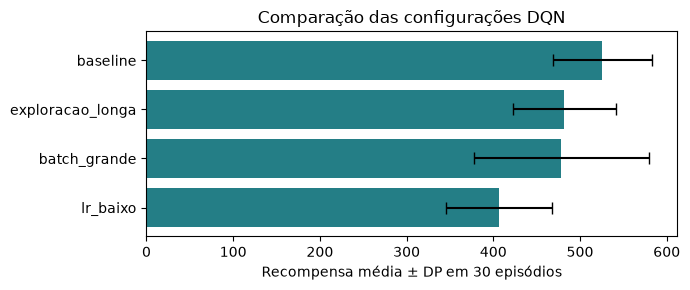

In [12]:
fig, ax = plt.subplots(figsize=(7, 3))
ax.barh(benchmark["Configuração"][::-1], benchmark["Recompensa média"][::-1],
        xerr=benchmark["DP"][::-1], capsize=4, color="#247e86")
ax.set_xlabel("Recompensa média ± DP em 30 episódios")
ax.set_title("Comparação das configurações DQN")
fig.tight_layout()
plt.show()

O baseline atingiu **525,6 ± 57,1**, a maior recompensa média observada, seguido de exploração longa (481,8), lote grande (478,5) e taxa menor (406,9). Assim, nenhuma das três alterações melhorou a média do baseline neste benchmark. Esse resultado motivou a escolha dos seus valores para o treinamento salvo e a avaliação operacional posterior.

A recompensa inclui incentivos à colheita e à irrigação, além da entrega. Portanto, a maior recompensa é um critério inicial de seleção, mas não basta para concluir que o modelo entrega mais plantas. Essa conclusão é examinada diretamente na comparação seguinte.

### 3.3.2. Comparação dos Modelos DQN Salvos

Foram comparados os melhores checkpoints (`best_model.zip`) de três treinos de 300.000 passos, todos com seed 42, lote 64 e o mesmo hash de ambiente. O v3 usa taxa 0,0005 e exploração 0,6; o v4 usa taxa 0,0001 e exploração 0,6; `dqn_v5_baseline_values`, chamado **Baseline** na tabela, usa taxa 0,0005 e exploração 0,3. O v4 difere da alternativa `lr_baixo` do benchmark, cuja exploração é 0,3.

Durante cada treinamento salvo, o `EvalCallback` avalia dez episódios a cada 10.000 passos e salva o checkpoint com maior recompensa média. Depois, cada `best_model` foi avaliado de forma determinística em **50 episódios**, reiniciando com seeds 10000 a 10049. Esse protocolo é distinto do benchmark dos modelos finais; seus resultados não devem ser misturados em uma única classificação.

A tabela abaixo é calculada com os 150 episódios incorporados ao notebook. **Taxa de entregas** mede o volume entregue entre as plantas disponíveis; **sucesso completo** exige entregar todas as 24 plantas no episódio.

In [13]:
# Dados por episódio incorporados ao relatório (50 por modelo).
# Cada lista mantém a ordem das seeds 10000 a 10049.
# S = sucesso; P = encerramento com perdas; T = limite de tempo.
dados_episodios = {
'dqn_v3': {
    "entregas": [15, 21, 23, 21, 24, 22, 21, 23, 24, 21, 6, 24, 20, 23, 23, 23, 24, 23, 21, 24, 21, 22, 15, 23, 23, 23, 21, 23, 21, 24, 23, 23, 24, 23, 24, 18, 23, 24, 21, 23, 21, 23, 18, 24, 23, 23, 23, 24, 20, 24],
    "mortes": [1, 0, 1, 0, 0, 1, 2, 1, 0, 1, 6, 0, 2, 1, 1, 1, 0, 1, 2, 0, 2, 0, 4, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 2, 1, 3, 1, 1, 0, 1, 1, 1, 0, 2, 0],
    "fins": 'TTPTSTTPSTTSTPPPSPTSTTTPTTTPTSPPSPSTTSTPPPTSPPPSTS',
},
'dqn_v4': {
    "entregas": [22, 18, 22, 22, 22, 22, 17, 12, 22, 22, 21, 20, 22, 22, 22, 19, 22, 22, 22, 20, 21, 20, 23, 22, 18, 23, 21, 18, 22, 16, 23, 22, 21, 22, 23, 23, 23, 16, 21, 23, 23, 22, 22, 22, 24, 21, 23, 22, 22, 20],
    "mortes": [1, 3, 2, 1, 1, 1, 0, 1, 2, 2, 3, 1, 2, 2, 2, 1, 1, 2, 1, 1, 2, 3, 0, 1, 3, 1, 3, 2, 1, 1, 0, 1, 2, 2, 0, 1, 1, 2, 3, 0, 1, 1, 2, 1, 0, 2, 1, 1, 2, 1],
    "fins": 'TTPTTTTTPPPTPPPTTPTTTTTTTPPTTTTTTPTPPTPTPTPTSTPTPT',
},
'dqn_v5_baseline_values': {
    "entregas": [20, 21, 22, 20, 22, 21, 23, 23, 23, 23, 20, 24, 23, 22, 23, 23, 23, 21, 23, 23, 22, 21, 23, 20, 22, 23, 22, 20, 23, 23, 23, 23, 19, 23, 20, 23, 23, 23, 20, 23, 21, 23, 22, 24, 23, 20, 22, 24, 24, 24],
    "mortes": [3, 2, 1, 2, 2, 3, 0, 0, 1, 1, 4, 0, 1, 1, 1, 0, 1, 2, 1, 1, 1, 2, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 3, 1, 3, 0, 2, 0, 0, 2, 0, 0, 0, 0],
    "fins": 'TTTTPPTTPPPSPTPTPTPPTTTTTTTTTTTPTPTTTTTPPTPSTTTSSS',
},
}
episodios = pd.DataFrame([
    {"run": nome, "seed": 10000+i, "delivered": entregas, "total": 24,
     "dead": mortes, "end": {"S": "success", "P": "no_work_left_with_losses", "T": "time_limit"}[fim]}
    for nome, dados in dados_episodios.items()
    for i, (entregas, mortes, fim) in enumerate(zip(dados["entregas"], dados["mortes"], dados["fins"]))
])


In [14]:
nomes = {"dqn_v3": "v3", "dqn_v4": "v4",
         "dqn_v5_baseline_values": "Baseline"}
linhas = []
for nome, grupo in episodios.groupby("run", sort=False):
    assert len(grupo) == 50
    linhas.append({
        "Modelo": nomes[nome],
        "Entregas médias / 24": grupo.delivered.mean(),
        "DP das entregas": grupo.delivered.std(ddof=0),
        "Entregas (%)": 100 * grupo.delivered.sum() / grupo.total.sum(),
        "Sucesso (%)": 100 * (grupo.end == "success").mean(),
        "Mortes médias": grupo.dead.mean(),
        "Limite de tempo (%)": 100 * (grupo.end == "time_limit").mean(),
    })
display(pd.DataFrame(linhas).round(2))

,Modelo,Entregas médias / 24,DP das entregas,Entregas (%),Sucesso (%),Mortes médias,Limite de tempo (%)
0,v3,21.82,3.06,90.92,24.0,0.94,42.0
1,v4,21.10,2.23,87.92,2.0,1.42,62.0
2,Baseline,22.18,1.32,92.42,10.0,0.94,60.0


### 3.3.3. Escolha Final do DQN: Prioridade ao Volume de Entregas

**O baseline foi selecionado porque o objetivo operacional adotado é maximizar a quantidade média de plantas entregues.** Nos 50 episódios, ele entregou **1.109 de 1.200 plantas possíveis**, correspondendo a **22,18 por episódio (92,42%)**. O v3 entregou 1.091 plantas, média de 21,82 (90,92%), e o v4 entregou 1.055, média de 21,10 (87,92%). Portanto, o baseline apresentou o maior volume entregue nesta avaliação, além de ter obtido a maior recompensa no benchmark.

O baseline também teve menor dispersão nas entregas: **DP de 1,32 planta**, contra 3,06 do v3 e 2,23 do v4. Seu pior episódio terminou com 19 entregas; no v3, houve um episódio com apenas seis. Esse resultado indica maior regularidade do baseline nesta amostra e ajuda a explicar sua maior média, mesmo sem liderar em sucesso completo.

O **v3 concluiu 12 de 50 episódios com 24/24 entregas (24%)**, enquanto o baseline concluiu cinco (10%) e o v4, um (2%). Assim, a escolha do baseline não significa que ele seja melhor em todas as métricas: ele foi preferido pelo volume médio entregue. Se o objetivo principal fosse maximizar a frequência de episódios sem nenhuma perda, o v3 seria o candidato favorecido pelos resultados disponíveis.

**Limitações:** a vantagem do baseline sobre o v3 foi de 18 plantas em 50 episódios, ou 0,36 por episódio. Isso sustenta uma escolha prática entre os modelos avaliados, mas não demonstra superioridade estatística geral. O baseline ainda atingiu o limite de tempo em 60% dos episódios. Nas inspeções visuais foram observadas ações repetidas no fim da tarefa. Os dados agregados não permitem medir a frequência nem determinar a causa desses ciclos. Para confirmar a escolha, seria necessário repetir os treinos com outras seeds e avaliar em novos episódios.

**Condições de comparação:** as seeds 10000–10049 foram utilizadas durante o desenvolvimento e são tratadas como avaliação padronizada, não como teste final intocado. Mesmas seeds não asseguram secagem idêntica entre políticas, pois as ações alteram quais plantas permanecem vivas. A secagem 0,005 do DQN também é menor que 0,02 dos testes avançados descritos para PPO/A2C, logo, os resultados não demonstram que o DQN seja intrinsecamente superior aos demais algoritmos.

## 4. Conclusões

**Visão Geral:** O projeto demonstrou a aplicação de algoritmos de Aprendizado por Reforço Profundo ao controle de um robô responsável por irrigar, colher e entregar plantas. Os experimentos com PPO, A2C e DQN mostraram que a aprendizagem depende tanto dos hiperparâmetros quanto da representação do estado e das condições do ambiente. Foram observados avanços no desempenho, embora ainda existam dificuldades para concluir todos os episódios sem perdas.

**Dificuldades Encontradas:** As principais dificuldades envolveram coordenar irrigação, colheita e retorno à base, utilizar adequadamente o inventário e evitar ações repetidas sem progresso. Esses comportamentos evidenciam que obter recompensas ao longo do episódio não garante concluir a tarefa, reforçando a importância de avaliar também entregas, mortes e interrupções por limite de tempo.

**Limitações:** O ambiente utiliza uma representação simplificada da secagem e uma grade de tamanho fixo. Além disso, os experimentos dos algoritmos tiveram diferenças na taxa de secagem e no orçamento de treinamento, o que limita a comparação direta. No DQN, foi utilizada uma única seed de treinamento por configuração, não sendo possível determinar a variabilidade entre treinamentos independentes.

**Trabalhos Futuros:** Recomenda-se padronizar as condições experimentais entre os algoritmos, repetir os treinamentos com diferentes seeds e avaliar os modelos em novos episódios. Também seria relevante investigar os ciclos de ações no final da tarefa e a adaptação a grades maiores e diferentes taxas de secagem. Como extensões do ambiente, podem ser explorados obstáculos dinâmicos e a atuação conjunta de múltiplos robôs.

Link da Apresentação: [Link do Vídeo](https://youtu.be/IFWAgUuZJQg)
